# Import libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import ucimlrepo as uciml

In [2]:
%matplotlib inline

# Create Model Class that inherits nn.Module

In [3]:
class Model(nn.Module):
    # Input Layer(4 neurons)
    # Hidden Layer(n neurons)
    # Output Layer(3 neurons)
    
    # define structure of neural network(number of neurons in each layer)
    def __init__(self, in_features, h1, h2, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1) # connecting input layer to hidden layer 1
        self.fc2 = nn.Linear(h1, h2) # connecting hidden layer 1 to hidden layer 2
        self.out = nn.Linear(h2, out_features) # connecting hidden layer 2 to output layer
    
    # define forward function (how data flows through the network)
    def forward(self, x):
        x = F.relu(self.fc1(x)) # applying ReLU activation function to the output of hidden layer 1
        x = F.relu(self.fc2(x)) # applying ReLU activation function to the output of hidden layer 2
        x = self.out(x) # output layer (no activation function, as we'll apply softmax later)
        
        return x

In [4]:
# Randomize with manual seed
torch.manual_seed(41)

# Create an instance of the model
model = Model(in_features=4, h1 = 8, h2 = 9, out_features=3)

# Load Data

In [5]:
data = uciml.fetch_ucirepo("iris").data
df = data.original
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Converting X and y in numpy array of float

In [6]:
X = df.drop("class", axis=1).values
y = df["class"].replace("Iris-setosa", 0.0).replace("Iris-versicolor", 1.0).replace("Iris-virginica", 2.0).astype(np.float64).values

# Modellazation

## Splitting in train and test set

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41, stratify=y)

## Converting the data in tensors

In [18]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

## Set criterion and optimezer

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

## Training Model

In [21]:
# set epochs
epochs = 100
losses = []

for i in range(epochs):
    # Forward propagation
    y_pred = model.forward(X_train_tensor)
    
    loss = criterion(y_pred, y_train_tensor) # calculate the loss
    losses.append(loss.detach().numpy()) # keep track of the loss

    # print every 10 epochs
    if i % 10 == 0:
        print(f"Epoch: {i} Loss: {loss}")
    
    # Backward propagation
    optimizer.zero_grad() # zero the gradients
    loss.backward() # backpropagate the loss
    optimizer.step() # update the weights

Epoch: 0 Loss: 0.0671110451221466
Epoch: 10 Loss: 0.061702799052000046
Epoch: 20 Loss: 0.05813022330403328
Epoch: 30 Loss: 0.05428343638777733
Epoch: 40 Loss: 0.050915446132421494
Epoch: 50 Loss: 0.048310842365026474
Epoch: 60 Loss: 0.046470899134874344
Epoch: 70 Loss: 0.045098062604665756
Epoch: 80 Loss: 0.043983228504657745
Epoch: 90 Loss: 0.043017275631427765


Text(0.5, 0, 'Epochs')

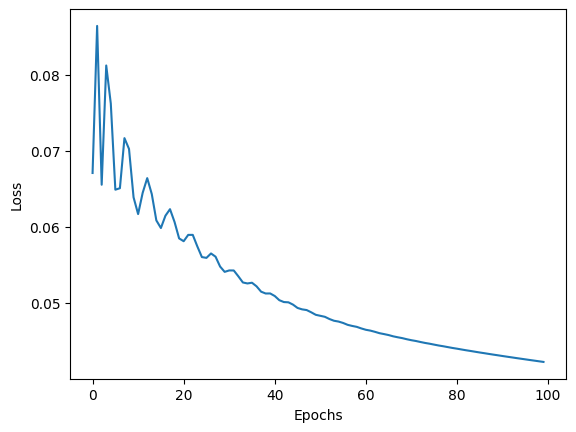

In [22]:
plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epochs")

# Testing Model 

In [23]:
with torch.no_grad(): # disable backprogagation
    y_eval = model.forward(X_test_tensor) # get predictions
    loss = criterion(y_eval, y_test_tensor) # get loss
    print(f"Test loss: {loss}") 

Test loss: 0.07407622784376144


Test Loss > Train Loss --> Overfitting

In [24]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test_tensor):
        y_eval = model.forward(data)
        
        # print predicted and actual values
        print(f'{i+1}.) {str(y_eval)} \t {y_test_tensor[i]}') 
        
        #check if the predicted class is the same as the actual class
        if y_eval.argmax().item() == y_test_tensor[i].item():
            correct += 1

print(f"Correct predictions: {correct}/{len(X_test_tensor)}")

1.) tensor([-3.9553,  7.2380, -1.0941]) 	 1
2.) tensor([-5.6014,  8.3466, -0.3959]) 	 1
3.) tensor([-4.6947,  7.4339, -0.5573]) 	 1
4.) tensor([10.4253, -2.0576, -9.8461]) 	 0
5.) tensor([ 8.9119, -0.9936, -9.0029]) 	 0
6.) tensor([-10.5741,   3.9600,   8.3047]) 	 2
7.) tensor([-14.5973,   2.3079,  13.7315]) 	 2
8.) tensor([-9.0992,  5.2730,  5.6854]) 	 1
9.) tensor([-5.3148,  6.6312,  0.7001]) 	 1
10.) tensor([-5.1110,  7.9462, -0.5521]) 	 1
11.) tensor([-5.8218,  8.2586, -0.1245]) 	 1
12.) tensor([-3.6490,  6.9294, -1.1480]) 	 1
13.) tensor([-11.8333,   3.0622,  10.2953]) 	 2
14.) tensor([-11.7135,   2.9613,  10.2514]) 	 2
15.) tensor([-16.7403,   0.7669,  17.1967]) 	 2
16.) tensor([-12.0110,   5.0391,   8.8574]) 	 2
17.) tensor([ 9.3179, -1.3159, -9.1933]) 	 0
18.) tensor([-4.7113,  7.7685, -0.7895]) 	 1
19.) tensor([ 11.1680,  -2.4468, -10.4059]) 	 0
20.) tensor([-8.8070,  5.7572,  4.9948]) 	 2
21.) tensor([ 7.8046, -0.2519, -8.3501]) 	 0
22.) tensor([ 9.9512, -1.7533, -9.5597]) 	 

# Evaluate new data on NN

In [25]:
# create a new iris data point
new_iris = torch.FloatTensor([[5.1, 3.5, 1.4, 0.2]])

# get prediction for new data
with torch.no_grad():
    print(model(new_iris))

tensor([[ 11.1635,  -2.3744, -10.4632]])


# Save and Loading Model

In [32]:
import os
os.makedirs("save_models", exist_ok=True)
torch.save(model.state_dict(), "save_models/irisNN.pt")

In [33]:
torchModel = Model(4, 8, 9, 3)
torchModel.load_state_dict(torch.load("save_models/irisNN.pt"))

<All keys matched successfully>

In [29]:
torchModel.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)